In [1]:
import sys
import math
import os
import torch
sys.path.append(os.path.abspath('../'))

from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from tqdm import tqdm

# Add both project root and src/ to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))  # <-- add this

from src.dataset import deterministic_sample
from src.egnn import EGNN
from src.fm import FlowMatching
from src.pbc_config import wrap, min_image, BOX
from src.utils import load_config, gpu_knn_graph_pbc_batch, scale_thetas

from src.validation import get_tpcf

import numpy as np
import pandas as pd 
import torch.nn as nn
import matplotlib.pyplot as plt

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helpers and Loading Data/Model

In [2]:
device = torch.device("cpu")
batch_size = 1

In [3]:
def find_equally_spaced_indices(arr, n):
    "Based on specific conditioning parameter."
    sorted_indices = np.argsort(arr)
    sorted_arr = arr[sorted_indices]
    min_val, max_val = sorted_arr[0], sorted_arr[-1]
    division_points = np.linspace(min_val, max_val, n)
    closest_indices = np.searchsorted(sorted_arr, division_points)
    closest_indices = np.clip(closest_indices, 0, len(arr) - 1)
    original_indices = sorted_indices[closest_indices]
    return original_indices

def det_prior(x1):
    g = torch.Generator(device=x1.device)
    g.manual_seed(42)

    x0 = torch.rand(x1.shape, device=x1.device, generator=g)
    return x0

def sample_xt(x0, x1, t, batch):
    t = t[batch]

    delta = min_image(x1 - x0, **BOX)
    mu_t = x0+t*delta
    sigma_t = 0
    
    x = mu_t + sigma_t * torch.randn_like(x1)

    return wrap(x, **BOX)

In [4]:
train_run = "20260311_020731"
config_dir = f"/gpfs/home4/bartb/T5000/results/run_{train_run}/train_configs.yaml"
config = load_config(config_dir)

In [5]:
egnn = EGNN(t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                input_node_d=config["model"]["egnn"]["input_node_d"],
                input_theta_d=5,
                theta_param_embd_dim=config["model"]["egnn"]["theta_param_embd_dim"],
                hidden_nf=config["model"]["egnn"]["hidden_nf"],
                latent_nf=config["model"]["egnn"]["latent_nf"],
                theta_nf=config["model"]["egnn"]["theta_nf"],
                n_layers=config["model"]["egnn"]["n_layers"],
                mlp_layers=config["model"]["egnn"]["mlp_layers"],
                single_layer=config["model"]["egnn"]["single_layer"],
                recurrent=config["model"]["egnn"]["recurrent"],
                activation=nn.SiLU(),
                norm=config["model"]["egnn"]["norm"],
                attention=config["model"]["egnn"]["attention"],
                scale_pred=config["model"]["egnn"]["scale_pred"],
                coords_weight=config["model"]["egnn"]["coords_weight"],
                norm_diff=config["model"]["egnn"]["norm_diff"])
    
model = FlowMatching(sigma_0=config["model"]["fm"]["sigma_0"],
                     sigma_sched=config["model"]["fm"]["sigma_sched"],
                     t_embed_dim=config["model"]["fm"]["t_embed_dim"],
                     version=config["model"]["fm"]["version"],
                     vnet=egnn,
                     batch_size=config["training"]["batch_size"],
                     prior=config["model"]["fm"]["prior"],
                     k=config["model"]["fm"]["k"],
                     t_embed=config["model"]["fm"]["t_embed"],
                     n_halos=config["model"]["fm"]["n_halos"],
                     dim=3
                     )

checkpoint = torch.load("/gpfs/home4/bartb/T5000/results/run_20260311_020731/model_epoch_1200.pth", map_location=torch.device('cpu'))
# checkpoint = torch.load(f"/gpfs/home4/bartb/T5000/results/run_{train_run}/model_final.pth", map_location=torch.device('cpu'))
new_state_dict = {k.replace("module.", ""): v for k, v in checkpoint["model_state"].items()}  # Remove "module."
model.load_state_dict(new_state_dict)

print("Loaded model")


        Initializing Flow Matching model with:
        - sigma_0: 0.2
        - sigma_sched: False
        - t_embed_dim: 64
        - version: icfm
        - batch_size: 16
        - prior: uniform
        - k: 32
        - t_embed: sinusoidal
        - n_halos: 5000
        - dim: 3
              
Loaded model


/scratch-local/bartb.20655588/ipykernel_912336/1935944237.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("/gpfs/home4/bartb/T5000/results/run_2

In [6]:
params = pd.read_csv("/gpfs/home4/bartb/T5000/Data/test_cosmology.csv").values
params_df = pd.read_csv("/gpfs/home4/bartb/T5000/Data/test_cosmology.csv")
cols = params_df.columns

## equally spaced based on Omega_m! : conditioning[:, 0]
equally_spaced = 20
params_idx_used = find_equally_spaced_indices(params[:,0], equally_spaced)
params_used = params[params_idx_used][::4]
params_used_df = pd.DataFrame(params_used, columns=cols)

print(f"Shape of true samples used: {params_used.shape}")
print(f"Condtioning:")
params_used_df.head()

Shape of true samples used: (5, 5)
Condtioning:


,Omega_m,Omega_b,h,n_s,sigma_8
0,0.1001,0.05047,0.8959,1.0103,0.9203
1,0.1839,0.04711,0.8675,1.0421,0.6845
2,0.2683,0.03749,0.7533,0.9845,0.9205
3,0.3539,0.06139,0.6681,0.8327,0.6243
4,0.4365,0.06281,0.7347,1.0699,0.9509


In [7]:
def sample(x0, batch, conditioning, model, k, device):
    ts = torch.linspace(0, 1, 50, device=device)
    dt = ts[1] - ts[0]

    h_in = torch.ones(x0.shape[0], 1, device=device)
    x_t = x0

    print(conditioning)
    
    model.eval()
    with torch.no_grad():
        for t in tqdm(ts):
            edge_index = gpu_knn_graph_pbc_batch(x_t, k, batch, device)
            t = t.view(1, 1)

            num_graphs = int(batch.max().item()) + 1
            t_embd = model.time_embedding(t).expand(num_graphs, -1)

            pred_v = model.vnet(h=h_in,
                                x=x_t, 
                                t_embed=t_embd,
                                batch=batch,
                                edge_index=edge_index,
                                theta=conditioning)
                
            x_t = x_t + pred_v * dt
            x_t = wrap(x_t, **BOX)
    
    x_final = x_t
    return x_final

In [8]:
x0 = det_prior(torch.zeros(5, 5000, 3)).reshape(-1, 3)
batch = torch.arange(0,5).repeat_interleave(5000, dim=-1)
conditioning = scale_thetas(torch.tensor(params_used)).float()
samples = sample(x0, batch, conditioning, model, 32, device)

tensor([[-1.0010,  0.0235,  0.9800,  0.0515,  0.6034],
        [-0.5816, -0.1446,  0.8379,  0.2106, -0.5774],
        [-0.1592, -0.6258,  0.2666, -0.0775,  0.6044],
        [ 0.2693,  0.5698, -0.1596, -0.8369, -0.8788],
        [ 0.6827,  0.6408,  0.1736,  0.3497,  0.7566]])


100%|██████████| 50/50 [07:36<00:00,  9.14s/it]


In [9]:
x0 = x0.reshape(5, 5000, 3)
samples = samples.reshape(5, 5000, 3)
c1, c2, c3, c4, c5 = samples
v1, v2, v3, v4, v5 = c1-x0[0], c2-x0[1], c3-x0[2], c4-x0[3], c5-x0[4]
diff_vectors = [v1, v2, v3, v4, v5]
diff_vectors = [vector.detach().numpy() for vector in diff_vectors]

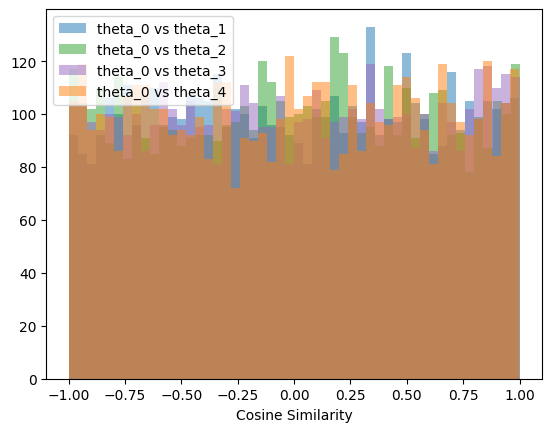

In [10]:
reference = diff_vectors[0]  # shape (5000, 3)
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

for idx, vector in enumerate(diff_vectors[1:], 1):
    cos_sim = np.sum(reference * vector, axis=1) / (
        np.linalg.norm(reference, axis=1) * np.linalg.norm(vector, axis=1)
    )
    # angle = np.degrees(np.arccos(np.clip(cos_sim, -1, 1)))
    plt.hist(cos_sim, bins=50, alpha=0.5, label=f'theta_0 vs theta_{idx}', color=colors[idx])

plt.xlabel(f"Cosine Similarity")
plt.legend()
plt.show()